In [1]:
# !pip install numpy pandas scikit-learn gensim pymorphy2 tqdm jupyter fasttext-wheel matplotlib nltk pyarrow

# Либы и функции

In [1]:
import warnings
import gc
import os 
import json
import psutil
import tempfile

import requests
import pandas as pd
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
from pandas import DataFrame

from tqdm import tqdm
tqdm.pandas()

import re
import nltk 
from nltk.corpus import stopwords
import pymorphy2
from functools import lru_cache

import fasttext

import numpy as np
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
RANDOM_STATE = 42

In [3]:
# фунции для сохранений и загрузок данных
MODELS_DIR = "models"
DATA_DIR = "data"

def checkpoint(
        df: DataFrame =None,
        checkpoint_name: str = 'temp',
):
    """
        Сохраняет DataFrame в формате parquet и освобождает память.
        Если df=None — загружает чекпоинт.
    """

    os.makedirs(DATA_DIR, exist_ok=True)
    filepath = os.path.join(DATA_DIR, checkpoint_name+'.parquet')

    # Сохранение
    if df is not None:
        df.to_parquet(filepath, index=False, compression='zstd')
        print("🟩 Данные сохранены")
        return None

    # Загрузка
    if os.path.exists(filepath):
        df = pd.read_parquet(filepath, engine='pyarrow', memory_map=True)
        print("🟩 Данные загружены")
        return df

    print("🧧 Чекпоинт не найден")
    return None

def dict_save(dict_: dict, name_dict: str):
    """
        Сохранение словаря в .json
    """
    with open(f"{DATA_DIR}/{name_dict}.json", "w", encoding="utf-8") as f:
        json.dump( dict_, f, ensure_ascii=False, indent=2)
    print(f"🟩 Словарь {name_dict} сохранён")

def dicts_saves(dicts_: list[tuple[dict, str]]):
    list_ = []
    for dict_, name_dict in dicts_:
        list_.append(dict_save(dict_, name_dict))
    return list_

def dict_load(name_dict: str):
    with open(f"{DATA_DIR}/{name_dict}.json", "r", encoding="utf-8") as f:
        dict_ = json.load(f)
    print(f"🟩 Словарь {name_dict} загружен")

def dicts_load(list_name_dicts: list) -> list:
    list_ = []
    for name_dict in list_name_dicts:
        list_.append(dict_load(name_dict))
    return list_

def target_dict_save(class_in_index_dict: dict, index_in_class_dict: dict):
    with open("data/class_mapping.json", "w", encoding="utf-8") as f:
        json.dump({
            "index_to_class": index_in_class_dict,
            "class_to_index": class_in_index_dict
        }, f, ensure_ascii=False, indent=2)
    print("🟩 Словарь таргетов сохранён")

def target_dict_load():
    """
        Return:
            index_in_class_dict, class_in_index_dict
    """
    with open("data/class_mapping.json", "r", encoding="utf-8") as f:
        mappings = json.load(f)
    
    index_in_class_dict = {int(k): v for k, v in mappings["index_to_class"].items()}
    
    class_in_index_dict = mappings["class_to_index"]
    class_in_index_dict = {k: int(v) for k, v in class_in_index_dict.items()}
    
    print("🟩 Словари таргетов загружены")
    return index_in_class_dict, class_in_index_dict



In [4]:
# Все функции, которые мы будем использовать далее

morph = pymorphy2.MorphAnalyzer()

@lru_cache(maxsize=200000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

nltk.download('stopwords')

STOPWORDS = set(stopwords.words('english')) | set(stopwords.words('russian'))

def tokenize_text(text: str, lemmatize: bool = False):
    text = re.sub(r'[^\w+\s]', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in STOPWORDS and len(word)>2]
    if lemmatize:
        words = [lemmatize_word(word) for word in words]
    return words


def tokenize_row(row, **kwargs):
    all_text = row['title']+row['text']
    tokens = tokenize_text(all_text, **kwargs)
    return tokens 

def tokenize_rows(df: DataFrame, **kwargs) -> list:
    return df.progress_apply(lambda row: tokenize_row(row, **kwargs), axis=1).tolist()

def plot_class_counts(counts):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(counts.index, counts.values)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                height,
                str(int(height)),
                ha='center',
                va='bottom')

    plt.title("Соотношение классов в данных")
    plt.xlabel("Класс")
    plt.ylabel("Количество")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

def get_or_tokenize(df=None, name: str = "tokens", **tokenize_kwargs):
    path = f"{DATA_DIR}/tokens_{name}.parquet"
    
    if os.path.exists(path):
        print(f"🟩 Загружаем готовые токены: {path}")
        return pd.read_parquet(path)["tokens"].tolist()
    
    print(f"Токенизируем данные: {name}")
    tokens = tokenize_rows(df, **tokenize_kwargs)
    
    pd.DataFrame({"tokens": tokens}).to_parquet(
        path,
        index=False,
        compression="zstd"
    )
    print(f"🟩 Сохранено: {path}")
    return tokens

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
from time import time

class EpochLogger(CallbackAny2Vec):
    def __init__(self, name="model"):
        self.epoch = 0
        self.name = name
        self.start_time = None
        self.loss = 0

    def on_epoch_begin(self, model):
        self.start_time = time()
        print(f"🐱‍👤 {self.name}: Эпоха {self.epoch+1} началась")

    def on_epoch_end(self, model):
        duration = time() - self.start_time
        new_loss = model.get_latest_training_loss()-self.loss
        self.loss = model.get_latest_training_loss()
        print(f"✅ {self.name}: Эпоха {self.epoch+1} закончилась, loss={new_loss}, время={duration:.1f}s")
        self.epoch += 1

def training_models_w2v(
        X_train, 
        save: bool = True, 
        max_worker: bool = True,
        **kwargs
):
    if max_worker:
        workers_count=os.cpu_count()
    else:
        workers_count=1
    
    print('Начало обучения W2V_SG')
    model_sg = Word2Vec(
        sentences=X_train,
        sg=1,
        workers=workers_count,
        callbacks=[EpochLogger("W2V_SG")],
        compute_loss=True,
    )
    print('🟢 W2V_SG обучена')
    
    print('Начало обучения W2V_CBOW')
    model_cbow = Word2Vec(
        sentences=X_train,
        sg=0,
        workers=workers_count,
        callbacks=[EpochLogger("W2V_CBOW")],
        compute_loss=True,
    )
    print('🟢 W2V_CBOW обучена')

    if save:
        sg_path = f"{MODELS_DIR}/word2vec_sg.model"
        cbow_path = f"{MODELS_DIR}/word2vec_cbow.model"
        model_sg.save(sg_path)
        model_cbow.save(cbow_path)
        print(f'🟢 Модели сохранены: {sg_path}, {cbow_path}')

    return model_sg, model_cbow 

def load_models_w2v(
        sg_path: str = None, 
        cbow_path: str = None
):
    if sg_path is None:
        sg_path = f"{MODELS_DIR}/word2vec_sg.model"
    if cbow_path is None:
        cbow_path = f"{MODELS_DIR}/word2vec_cbow.model"

    model_sg = Word2Vec.load(sg_path)
    model_cbow = Word2Vec.load(cbow_path)

    print(f'🟢 Модели успешно загружены: {sg_path}, {cbow_path}')
    return model_sg, model_cbow

In [6]:
def text_to_vec(text: str, model):
    text = tokenize_text(text)

    vectors = []
    for token in text:
        if token in model.wv:
            vectors.append(model.wv[token])
    
    if not vectors:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

def texts_to_vectors(series: pd.Series, model) -> np.ndarray:
    return np.array([
        text_to_vec(val, model)
        for val in tqdm(series, desc="Обработка строк")
    ], dtype=np.float32)


def vectorize_text_df(
    df: pd.DataFrame,
    model,
    text_columns: list = None,
    prefix: str = "vec_",
) -> pd.DataFrame:
    if text_columns is None:
        text_columns = df.columns
    
    df = df.copy()
    print("\nСтарт веторизации 🫠")
    for col in text_columns:
            
        vectors_2d = texts_to_vectors(df[col], model)
        
        new_cols = [f"{prefix}{col}_{i}" for i in range(vectors_2d.shape[1])]
        
        df[new_cols] = vectors_2d
        df = df.drop(col, axis=1)
    
    print("Веторизации окочена 😎")
    return df

def conf_matrix_vision(y_test, y_pred, classes, title: str = ''):

    cf_m = confusion_matrix(y_test, y_pred)
    cf_disp = ConfusionMatrixDisplay(cf_m, display_labels=classes)

    cf_disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix {title}')
    plt.xticks(rotation=90)
    plt.show()

# Download Data

In [8]:
url = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.1/lenta-ru-news.csv.bz2"

response = requests.get(url, stream=True)
response.raise_for_status()

with open("lenta-ru-news.csv.bz2", "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print('Dataset скачан')

Dataset скачан


In [8]:
df = pd.read_csv("lenta-ru-news.csv.bz2", usecols=['title', 'text', 'topic'])
df.head()

C:\Users\acer\AppData\Local\Temp\ipykernel_11080\783554467.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lenta-ru-news.csv.bz2", usecols=['title', 'text', 'topic'])


,title,text,topic
0,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека
1,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека
2,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека
3,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека
4,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека


# Preprocessing

## Очистка

In [9]:
orig_shape = df.shape
df = df.drop_duplicates()
df = df.dropna()
new_shape = df.shape
print('Размеры датасета:')
print(f'* изначально: {orig_shape}')
print(f'* после очистки: {new_shape}')

Размеры датасета:
* изначально: (800975, 3)
* после очистки: (738949, 3)


## Обработка текстов

Смотрим как работает наш токенизатор на собственном примере входных данных.

In [10]:
test_text = """
Воспоминания о Дрездене 1945-го года возвращались снова и снова. Билли видел, как город превращается в руины после бомбёжки. Он пытался понять, как один момент может изменить всё, как маленькое решение или случайность формируют судьбы людей. Внутри него возникало чувство, что всё это — лишь часть огромного, непостижимого узора времени.
""" # фрагмент из произведения "Бойня номер 5" Автор: Курт Воннегут

tok_test_lem = tokenize_text(test_text, True)
tok_test_no_lem = tokenize_text(test_text, False)
print(f'Пример с лематизацией:\n\tКоличество:{len(tok_test_lem)}\n\t{tok_test_lem[:10]}')
print(f'Пример без лематизации:\n\tКоличество:{len(tok_test_no_lem)}\n\t{tok_test_no_lem[:10]}')

Пример с лематизацией:
	Количество:35
	['воспоминание', 'дрезден', '1945', 'год', 'возвращаться', 'снова', 'снова', 'билли', 'видеть', 'город']
Пример без лематизации:
	Количество:35
	['воспоминания', 'дрездене', '1945', 'года', 'возвращались', 'снова', 'снова', 'билли', 'видел', 'город']


Проверка работы с строчкой из DF

In [11]:
row = df[['title','text']].iloc[0]

tokens_row = tokenize_row(row, lemmatize=True)
print('Токены строчки:', tokens_row)

Токены строчки: ['1914', 'русский', 'войско', 'вступить', 'предел', 'венгрия', 'бой', 'сопоцкина', 'друскеник', 'закончиться', 'отступление', 'германец', 'неприятель', 'приблизиться', 'север', 'осовца', 'начать', 'артиллерийский', 'борьба', 'крепость', 'артиллерийский', 'бой', 'принимать', 'участие', 'тяжёлый', 'калибр', 'ранний', 'утро', 'сентябрь', 'огонь', 'достигнуть', 'значительный', 'напряжение', 'попытка', 'германский', 'пехота', 'пробиться', 'близкий', 'крепость', 'отразить', 'галиция', 'занять', 'дембица', 'больший', 'колонна', 'отступать', 'шоссе', 'перемышль', 'санок', 'обстреливаться', 'высота', 'наш', 'батарея', 'бежать', 'бросить', 'парка', 'обоз', 'автомобиль', 'вылазка', 'гарнизон', 'перемышль', 'оставаться', 'безуспешный', 'продолжаться', 'отступление', 'австриец', 'обнаруживаться', 'полный', 'перемешивание', 'часть', 'захватываться', 'новый', 'партия', 'пленный', 'орудие', 'прочий', 'материальный', 'часть', 'перевал', 'ужок', 'разбить', 'неприятельский', 'отряд', 'взя

Проверка токенизации 5-ти первых строчек

In [12]:
tokenize_rows(df.head())

100%|██████████| 5/5 [00:00<00:00, 2499.88it/s]


[['1914',
  'русские',
  'войска',
  'вступили',
  'пределы',
  'венгрии',
  'бои',
  'сопоцкина',
  'друскеник',
  'закончились',
  'отступлением',
  'германцев',
  'неприятель',
  'приблизившись',
  'севера',
  'осовцу',
  'начал',
  'артиллерийскую',
  'борьбу',
  'крепостью',
  'артиллерийском',
  'бою',
  'принимают',
  'участие',
  'тяжелые',
  'калибры',
  'раннего',
  'утра',
  'сентября',
  'огонь',
  'достиг',
  'значительного',
  'напряжения',
  'попытка',
  'германской',
  'пехоты',
  'пробиться',
  'ближе',
  'крепости',
  'отражена',
  'галиции',
  'заняли',
  'дембицу',
  'большая',
  'колонна',
  'отступавшая',
  'шоссе',
  'перемышля',
  'саноку',
  'обстреливалась',
  'высот',
  'нашей',
  'батареей',
  'бежала',
  'бросив',
  'парки',
  'обоз',
  'автомобили',
  'вылазки',
  'гарнизона',
  'перемышля',
  'остаются',
  'безуспешными',
  'продолжающемся',
  'отступлении',
  'австрийцев',
  'обнаруживается',
  'полное',
  'перемешивание',
  'частей',
  'захватываются',


Токенизация работает и теперь при необходимости мы можем токенизировать все имеющиеся строчки *DataFrame*

## Проверка распределения таргета

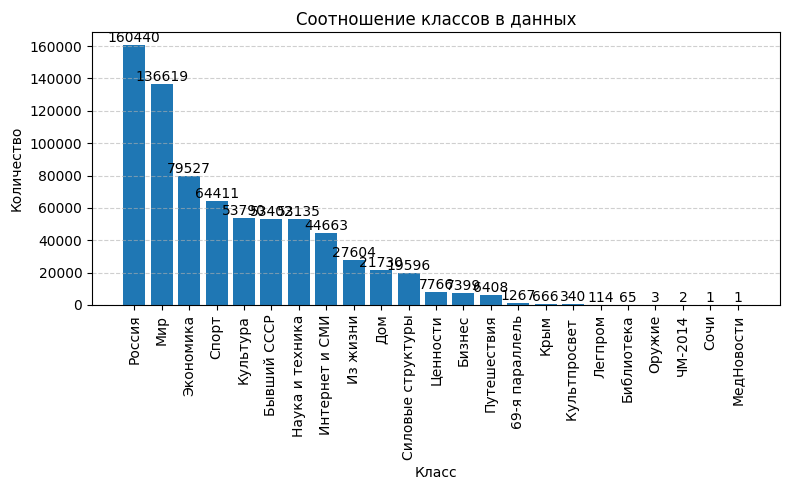

In [13]:
counts = df['topic'].value_counts()
plot_class_counts(counts)

Обьединим классы количество которых меньше 10k в общий класс `Другое`

In [14]:
class_microcount = counts[counts < 10000].index.to_numpy()
df['topic'] = df['topic'].apply(lambda x: 'Другое' if x in class_microcount else x)

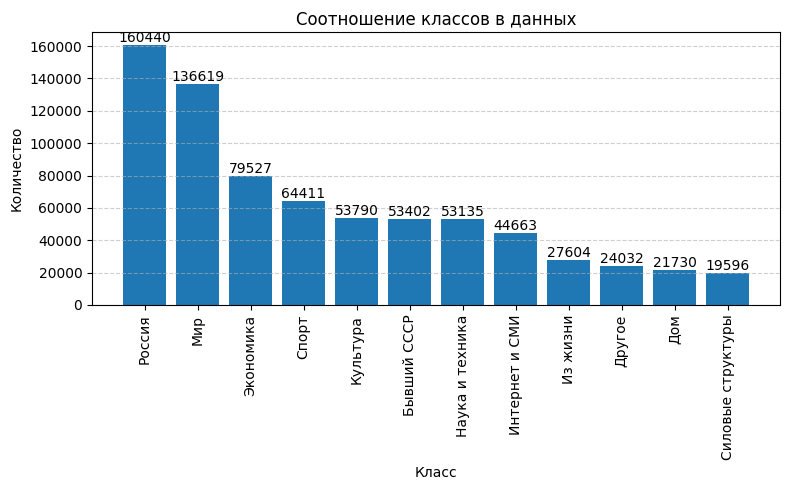

In [15]:
counts_new = df['topic'].value_counts()
plot_class_counts(counts_new)

## Деление данные на тренировочные и тестовые

In [16]:
X_train, X_test, y_train, y_test = train_test_split(df[['title', 'text']], df['topic'], train_size=0.8, random_state=RANDOM_STATE)

print(f'Размер тренировочных данных x={X_train.shape} y={y_train.shape}')
print(f'Размер тестовых данных      x={X_test.shape} y={y_test.shape}')

Размер тренировочных данных x=(591159, 2) y=(591159,)
Размер тестовых данных      x=(147790, 2) y=(147790,)


## Создание словаря таргетов

In [17]:
y_train_unique = sorted(y_train.unique())

index_in_class_dict = {index: y for index,y in enumerate(y_train_unique)}
class_in_index_dict = {y: index for index,y in enumerate(y_train_unique)}

print('Словарь indx -> text', index_in_class_dict) 
print('Словарь text -> indx', class_in_index_dict) 

Словарь indx -> text {0: 'Бывший СССР', 1: 'Дом', 2: 'Другое', 3: 'Из жизни', 4: 'Интернет и СМИ', 5: 'Культура', 6: 'Мир', 7: 'Наука и техника', 8: 'Россия', 9: 'Силовые структуры', 10: 'Спорт', 11: 'Экономика'}
Словарь text -> indx {'Бывший СССР': 0, 'Дом': 1, 'Другое': 2, 'Из жизни': 3, 'Интернет и СМИ': 4, 'Культура': 5, 'Мир': 6, 'Наука и техника': 7, 'Россия': 8, 'Силовые структуры': 9, 'Спорт': 10, 'Экономика': 11}


In [18]:
y_train = y_train.apply(lambda x: class_in_index_dict[x])
y_test = y_test.apply(lambda x: class_in_index_dict[x])

## Токенизация

In [27]:
X_train_tokens = get_or_tokenize(X_train, "X_train")
X_test_tokens = get_or_tokenize(X_test, "X_test")

🟩 Загружаем готовые токены: data/tokens_X_train.parquet
Токенизируем данные: X_test


100%|██████████| 147790/147790 [00:14<00:00, 10335.45it/s]


🟩 Сохранено: data/tokens_X_test.parquet


In [28]:
# ============================ ЧЕКПОИНТ ============================
# ===== Сохранение
checkpoint(X_train, 'X_train_str_df')
checkpoint(X_test, 'X_test_str_df')
checkpoint(y_train.to_frame(name='target'), 'y_train_int_df')
checkpoint(y_test.to_frame(name='target'), 'y_test_int_df')
target_dict_save(class_in_index_dict, index_in_class_dict)

# ===== Загрузка
X_train_str_df = checkpoint(checkpoint_name='X_train_str_df')
X_test_str_df = checkpoint(checkpoint_name='X_test_str_df')

y_train_int_df = checkpoint(checkpoint_name='y_train_int_df')
y_test_int_df = checkpoint(checkpoint_name='y_test_int_df')

index_in_class_dict, class_in_index_dict = target_dict_load()
classes = list(index_in_class_dict.values()) 
# ============================ ЧЕКПОИНТ ============================

🟩 Данные сохранены и память очищена
🟩 Данные сохранены и память очищена
🟩 Данные сохранены и память очищена
🟩 Данные сохранены и память очищена
🟩 Словарь таргетов сохранён
🟩 Данные загружены
🟩 Данные загружены
🟩 Данные загружены
🟩 Данные загружены
🟩 Словари таргетов загружены


Информация по *checkpoint*:

* *X_train* и *X_test*:
    * `pd.DataFrame` датафреймы с str значениями
* *y_train* и *y_test*:
    * `pd.DataFrame` с одним столбцом числовых значений
* *index_in_class_dict*, *class_in_index_dict*:
    *  словари для преобразований target из `int` -> `str` и наоборот 

# Word2Vec

In [ ]:
# Обучаем если у нас нет моделей (автоматически сохраняются)
model_sg, model_cbow = training_models_w2v(X_train_tokens) 

# Загружаем, если у нас уже есть готовые модели
model_sg, model_cbow = load_models_w2v()

🟢 Модели успешно загружены: models/word2vec_sg.model, models/word2vec_cbow.model


In [30]:
X_train_cbow_vec = vectorize_text_df(X_train_str_df, model_cbow)
X_test_cbow_vec = vectorize_text_df(X_test_str_df, model_cbow)

X_train_sg_vec = vectorize_text_df(X_train_str_df, model_sg)
X_test_sg_vec = vectorize_text_df(X_test_str_df, model_sg)


Старт веторизации 🫠


Обработка строк: 100%|██████████| 591159/591159 [03:28<00:00, 2832.46it/s]


Веторизации окочена 😎

Старт веторизации 🫠


Обработка строк: 100%|██████████| 147790/147790 [00:33<00:00, 4356.05it/s]


Веторизации окочена 😎

Старт веторизации 🫠


Обработка строк: 100%|██████████| 591159/591159 [02:00<00:00, 4889.06it/s]


Веторизации окочена 😎

Старт веторизации 🫠


Обработка строк: 100%|██████████| 147790/147790 [00:29<00:00, 5001.54it/s]


Веторизации окочена 😎


In [31]:
# при запусске на стандартных 100 итерациях модель не сходится, поэтому увеличим до 500 итераций
lr_cbow = LogisticRegression(random_state=RANDOM_STATE, max_iter=500).fit(X_train_cbow_vec, y_train)
lr_sg = LogisticRegression(random_state=RANDOM_STATE, max_iter=500).fit(X_train_sg_vec, y_train)

In [32]:
y_pred_cbow = lr_cbow.predict(X_test_cbow_vec)
y_pred_sg = lr_sg.predict(X_test_sg_vec)

In [33]:
from sklearn.metrics import classification_report

dict_res_cbow = classification_report(y_test, y_pred_cbow, target_names=classes, digits=3, output_dict=True)
dict_res_sg = classification_report(y_test, y_pred_sg, target_names=classes, digits=3, output_dict=True)

In [ ]:
# сохраним результаты, что бы потом сравнить на сколько хорошо работают обученные нами модели
dict_save(dict_res_cbow, "dict_res_cbow")
dict_save(dict_res_sg, "dict_res_sg")

🟩 Словарь dict_res_cbow сохранён
🟩 Словарь dict_res_sg сохранён


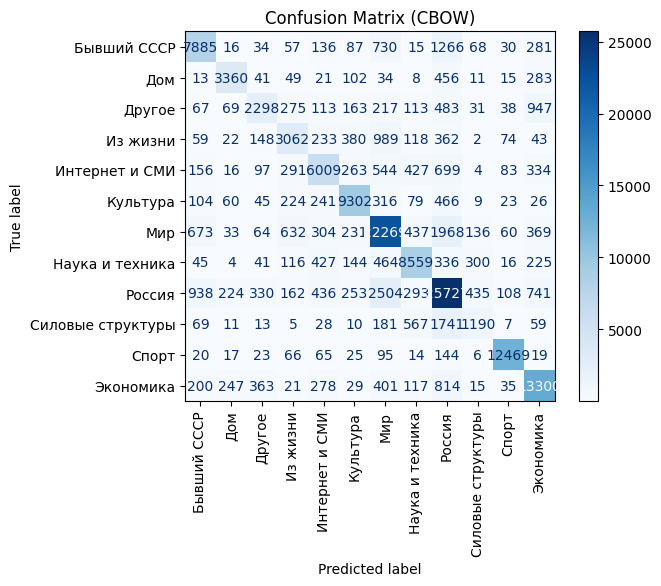

In [35]:
conf_matrix_vision(y_test, y_pred_cbow, classes, title="(CBOW)")

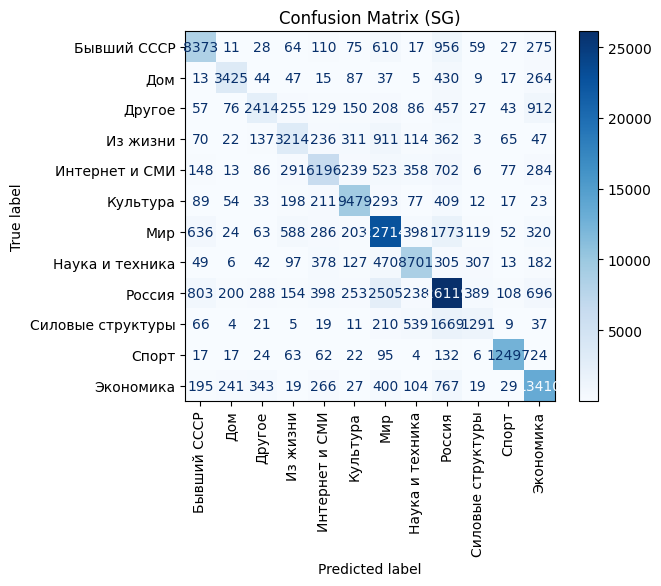

In [36]:
conf_matrix_vision(y_test, y_pred_sg, classes, title="(SG)")

In [ ]:
# ============================ ЧЕКПОИНТ ============================

# ===== Cохранение
checkpoint(X_test_cbow_vec, 'chekpoint_X_test_cbow_vec')
checkpoint(X_test_sg_vec, 'chekpoint_X_test_sg_vec')
checkpoint(y_train.to_frame(name='target'), 'chekpoint_y_train')
checkpoint(y_test.to_frame(name='target'), 'chekpoint_y_test')
del y_pred_sg, y_pred_cbow
gc.collect()

# ============================ ЧЕКПОИНТ ============================

# FastText

In [8]:
# ============================ ЧЕКПОИНТ ============================

# ===== Загрузка
X_train_str = checkpoint(checkpoint_name='X_train_str_df')
X_test_str = checkpoint(checkpoint_name='X_test_str_df')
y_test_int_df = checkpoint(checkpoint_name='y_test_int_df')
y_train_int_df = checkpoint(checkpoint_name='y_train_int_df')

index_in_class_dict, class_in_index_dict = target_dict_load()
classes = list(index_in_class_dict.values())

# ============================ ЧЕКПОИНТ ============================

🟩 Данные загружены
🟩 Данные загружены
🟩 Данные загружены
🟩 Данные загружены
🟩 Словари таргетов загружены


In [9]:
print(type(X_train_str))
print(type(X_test_str))
print(type(y_test_int_df))
print(type(y_train_int_df))
print(X_train_str.describe())
print(y_train_int_df.describe())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
                                              title           text
count                                        591159         591159
unique                                       589316         590468
top     В Москве объявлено штормовое предупреждение  РИА "Новости"
freq                                             14            220
              target
count  591159.000000
mean        6.455813
std         3.093311
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        11.000000


## Обучение моделей

In [10]:
def combine_title_text(df):
    """Из df с колонками title и text делает чистую колонку text"""
    df = df.copy()
    df['title'] = df['title'].fillna('').astype(str)
    df['text']  = df['text'].fillna('').astype(str)
    
    combined = df['title'] + " " + df['text']
    combined = combined.str.replace(r'\s+', ' ', regex=True).str.strip()
    
    combined = combined.str.replace(r'[\n\r\t]+', ' ', regex=True)
    
    return combined

X_train_combined = combine_title_text(X_train_str)
X_test_combined  = combine_title_text(X_test_str)

print("Пример тренировочного текста:")
print(X_train_combined.iloc[0][:150], "...")
print("\nПустых строк в train:", (X_train_combined.str.strip() == '').sum())
print("Пустых строк в test :", (X_test_combined .str.strip() == '').sum())

Пример тренировочного текста:
Пушков назвал истерикой поведение посла США в Чехии Председатель комитета по международным делам Госдумы Алексей Пушков назвал истерикой поведение пос ...

Пустых строк в train: 0
Пустых строк в test : 0


In [11]:
target_col = y_train_int_df.columns[0] 

y_train_labels = y_train_int_df[target_col].map(
    lambda x: f"__label__{index_in_class_dict.get(int(x), 'UNKNOWN')}"
)

y_test_labels = y_test_int_df[target_col].map(
    lambda x: f"__label__{index_in_class_dict.get(int(x), 'UNKNOWN')}"
)

print("UNKNOWN в train labels:", (y_train_labels == '__label__UNKNOWN').sum())
print("UNKNOWN в test  labels:", (y_test_labels  == '__label__UNKNOWN').sum())

UNKNOWN в train labels: 0
UNKNOWN в test  labels: 0


In [12]:
train_data = pd.DataFrame({
    'label': y_train_labels,
    'text':  X_train_combined
})

test_data = pd.DataFrame({
    'label': y_test_labels,
    'text':  X_test_combined
})

In [14]:
train_data.to_csv(
    'data/train_fasttext.txt',
    sep=' ',
    header=False,
    index=False,
    quoting=3,
    escapechar='\\'
)

test_data.to_csv(
    'data/test_fasttext.txt',
    sep=' ',
    header=False,
    index=False,
    quoting=3,
    escapechar='\\'
)

In [15]:
model_ft = fasttext.train_supervised('data/train_fasttext.txt')

In [16]:
model_ft.save_model('models/ft.bin')

## Загрузка

In [17]:
model_ft = fasttext.load_model('models/ft.bin')

## Предсказания

In [18]:
test_texts = X_test_combined.tolist()

In [19]:
pred_labels, pred_probs = model_ft.predict(test_texts, k=1)

In [20]:
y_pred_str = [lbl[0].replace('__label__', '') for lbl in pred_labels]

In [21]:
y_pred_int = np.array([
    class_in_index_dict.get(label, -1)
    for label in y_pred_str
])

In [22]:
y_true_int = y_test_int_df[target_col].astype(int).to_numpy()

In [23]:
from sklearn.metrics import classification_report

dict_res = classification_report(y_true_int, y_true_int, target_names=classes, digits=3, output_dict=True)

dict_save(dict_res, "dict_res_ft")

🟩 Словарь dict_res_ft сохранён


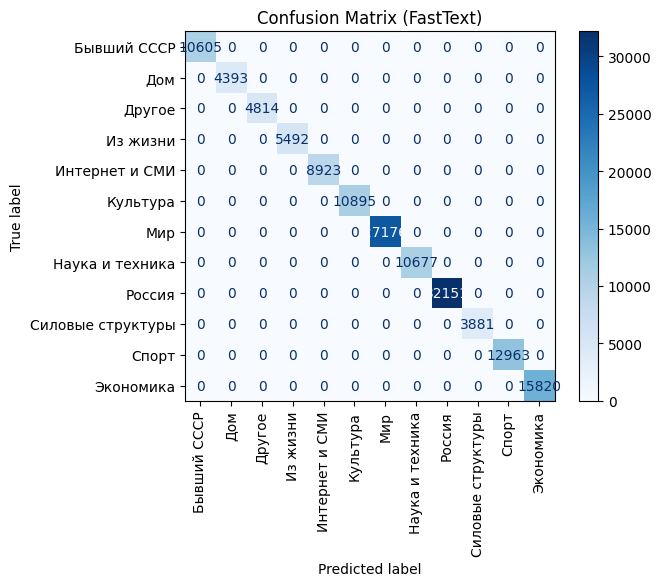

In [24]:
conf_matrix_vision(y_true_int, y_true_int, classes, title="(FastText)")